# 05. LDA 토픽 모델링

04에서 HDBSCAN으로 5개 클러스터(Actor)를 도출했습니다.
각 클러스터가 어떤 주제의 리뷰 모음인지 해석하기 위해, 클러스터별로 LDA를 적용하여 토픽 키워드를 추출합니다.

> 본 노트북은 **클러스터 0** 기준으로 전체 과정을 보여줍니다. 나머지 클러스터(1~4)는 동일한 파이프라인을 팀원들이 각각 수행했으며, 최종 결과를 요약 표로 정리합니다.

## 1. 데이터 로드 + 클러스터 0 필터링

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_pickle('df_labels.pkl')
df = df[['title', 'clean_content', 'cluster_1400_7']]
df = df[df['cluster_1400_7'] == 0]
print(f'클러스터 0 리뷰 수: {len(df):,}')
df.head()

## 2. 텍스트 전처리

임베딩(02)은 문서 간 유사도 기반 클러스터링을 위한 것이었고, LDA는 단어 빈도(BoW) 기반으로 토픽을 추출하므로 형태소 분석을 별도로 수행합니다.

1. 정규식으로 특수문자 제거
2. 15자 미만 짧은 글 제거
3. Okt 형태소 분석: 명사/형용사/동사 추출 + 불용어 제거

In [ ]:
import re
from tqdm import tqdm
from konlpy.tag import Okt

# 정규식 클리닝
def re_pattern(string):
    pattern = re.compile(r'[^a-zA-Z가-힣\s\.\?\!]')
    string = re.sub(pattern, ' ', string)
    pattern2 = re.compile(r'\s+')
    result = re.sub(pattern2, ' ', string)
    return result

# 짧은 글 제거
for n, i in enumerate(df['clean_content']):
    if len(i) < 15:
        df = df.drop([n])

df['re_clean_content'] = df['clean_content'].apply(lambda x: re_pattern(x))

# Okt 형태소 분석 + 불용어 제거
okt = Okt()
stopwords_df = pd.read_csv('ko-stopwords.csv')
stopwords = set(stopwords_df['stopwords'])

def okt_pos_tagging(string):
    pos_words = okt.pos(string, stem=True, norm=True)
    result = [word for word, tag in pos_words if word not in stopwords if tag in {'Noun', 'Adjective', 'Verb'}]
    return result

tqdm.pandas()
df['tagged_review'] = df['re_clean_content'].progress_apply(lambda x: okt_pos_tagging(x))
df.head()

## 3. LDA 사전 및 코퍼스 생성

In [ ]:
import gensim
from gensim.corpora import Dictionary

all_documents = list(df['tagged_review'])
dictionary = Dictionary(all_documents)

corpus = [dictionary.doc2bow(doc) for doc in all_documents]
print(f'사전 크기: {len(dictionary):,}')
print(f'코퍼스 크기: {len(corpus):,}')

## 4. 최적 토픽 수 선정

Perplexity(높을수록 좋음)와 Coherence(높을수록 좋음)를 토픽 수 2~9에 대해 비교합니다.

In [ ]:
from gensim.models import CoherenceModel
import matplotlib.pyplot as plt

perplexity_values = []
coherence_values = []

for i in tqdm(range(2, 10)):
    ldamodel = gensim.models.ldamodel.LdaModel(
        corpus, num_topics=i, id2word=dictionary,
        passes=20, iterations=50, random_state=42
    )
    perplexity_values.append(ldamodel.log_perplexity(corpus))
    
    coherence_model = CoherenceModel(
        model=ldamodel, texts=all_documents,
        dictionary=dictionary, topn=3
    )
    coherence_values.append(coherence_model.get_coherence())

#  그래프
x = range(2, 10)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x, perplexity_values)
axes[0].set_xlabel('Number of Topics')
axes[0].set_ylabel('Perplexity Score')
axes[0].set_title('Perplexity by Topic Count')

axes[1].plot(x, coherence_values)
axes[1].set_xlabel('Number of Topics')
axes[1].set_ylabel('Coherence Score')
axes[1].set_title('Coherence by Topic Count')

plt.tight_layout()
plt.show()

**토픽 수 선정 결과**: Perplexity는 3에서 피크, Coherence도 3에서 첫 번째 피크(0.69). 8에서 Coherence가 더 높지만 토픽 8개는 해석이 어려우므로, **토픽 3개**로 결정. 토픽 2, 4로도 비교했으나 키워드 분리가 불명확하여 최종 3으로 확정

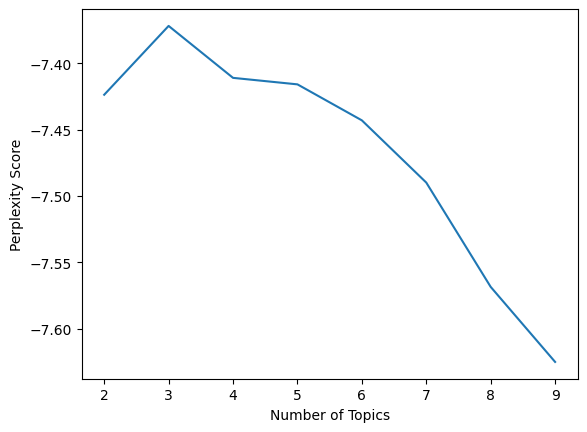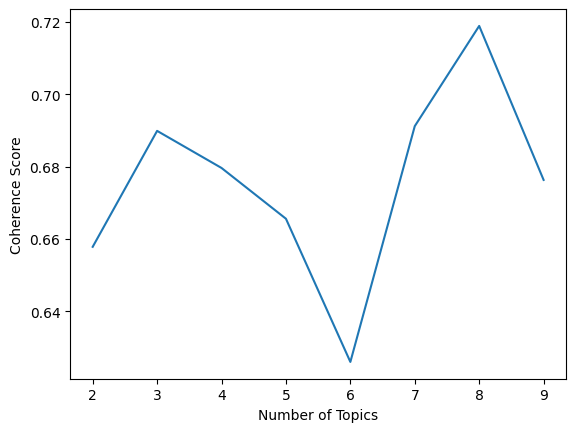

## 5. LDA 최종 모델 학습

In [ ]:
# LDA 최종 모델 (topic=3)
topic_num = 3
ldamodel = gensim.models.ldamodel.LdaModel(
    corpus,
    num_topics=topic_num,
    id2word=dictionary,
    passes=20,
    iterations=50,
    random_state=42
)

# 토픽별 키워드 확인
for idx, topic in ldamodel.print_topics(-1, num_words=10):
    print(f'Topic {idx}: {topic}')

In [ ]:
# 문서별 가장 확률 높은 토픽 할당
action_align = []
for doc in tqdm(ldamodel.get_document_topics(corpus)):
    label = []
    value = []
    for score in doc:
        label.append(score[0])
        value.append(score[1])
    max_index = np.argmax(value)
    action_align.append(label[max_index])

df['topic'] = action_align
print(df['topic'].value_counts())

## 6. pyLDAvis 시각화

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

prepared_data = gensimvis.prepare(ldamodel, corpus, dictionary)
pyLDAvis.display(prepared_data)

In [ ]:
# LDA 토픽 할당 결과 저장
df['topic'] = action_align
df.to_csv('df_cluster_0_topic.csv', index=False, encoding='utf-8-sig')
print('저장 완료: df_cluster_0_topic.csv')

## 7. 전체 클러스터 LDA 결과 요약

동일한 파이프라인을 클러스터 0~4에 각각 적용한 결과입니다.

| 클러스터 | 소제목 | 토픽 수 | 토픽 키워드 요약 |
|---------|--------|---------|----------------|
| 0 | 헬스케어형 펫 보호자 | 3 | 일상 건강 관리 / 수술·재활·병원 / 영양제·보조제 |
| 1 | 이제 막 키우기 시작한 초보 펫 보호자 | 4 | 질병 예방·정보 검색 / 배변·위생 / 용품 구매·리뷰 / 피부·털 관리 |
| 2 | 펫과 동반 여행을 원하는 보호자 | 3 | 여행 준비·경험 공유 / 비행기 탑승 / 숙소·프리미엄 경험 |
| 3 | '오늘도 산책 갈까?' 반려동물 산책 담당 | 3 | 산책·날씨 고민 / 놀이 장소 / 사진·공유 |
| 4 | 펫의 행동 교정을 원하는 보호자 | 4 | 분리 불안·교정 / 맡길 곳 / 이웃 충돌·훈련 / 이별·사별 감정 |

> 각 클러스터의 토픽 키워드는 다음 단계(06 CAM)에서 Action으로 정의되어 Opportunity Score 산출에 활용됩니다.

## 결론

1. 클러스터별 LDA를 적용하여 **각 클러스터의 주요 토픽 키워드**를 추출
2. Perplexity + Coherence 기반으로 토픽 수를 결정 (클러스터 0 → 3개)
3. 5개 클러스터가 각각 **뚜렷한 주제 영역**을 가지고 있음을 확인
4. 다음 단계(06)에서 이 토픽들을 Action으로 정의하고, 감성분석 + Opportunity Score로 개선 우선순위를 도출